# **E-Commerce Customer Analytics**
### **Cohort Retention Analysis**

**Notebook:** 06 of 06  
**Goal:** Track how well customers retained month by month after their first purchase. Cohort retention shows which acquisition months produced the most loyal customers and where drop-off is happening.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

os.makedirs("/content/outputs/charts", exist_ok=True)
os.makedirs("/content/outputs/tables", exist_ok=True)

In [3]:
df_tx = pd.read_csv(
    "online_retail_cleaned.csv",
    parse_dates=["InvoiceDate"]
)
df_tx.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**Assign Cohort Month**

A cohort is defined by the month a customer made their very first purchase. Every customer belongs to exactly one cohort, the month they were acquired.

In [4]:
df_tx["CohortMonth"] = df_tx.groupby("CustomerID")["InvoiceDate"] \
                            .transform("min").dt.to_period("M")
df_tx.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [5]:
df_tx["TransactionMonth"] = df_tx["InvoiceDate"].dt.to_period("M")

In [6]:
df_tx[["CustomerID", "InvoiceDate", "CohortMonth", "TransactionMonth"]].head(5)

,CustomerID,InvoiceDate,CohortMonth,TransactionMonth
0,17850,2010-12-01 08:26:00,2010-12,2010-12
1,17850,2010-12-01 08:26:00,2010-12,2010-12
2,17850,2010-12-01 08:26:00,2010-12,2010-12
3,17850,2010-12-01 08:26:00,2010-12,2010-12
4,17850,2010-12-01 08:26:00,2010-12,2010-12


In [7]:
# Calculate Cohort Index
df_tx["CohortIndex"] = (
    df_tx["TransactionMonth"] - df_tx["CohortMonth"]
).apply(lambda x: x.n)
df_tx[["CustomerID", "InvoiceDate", "CohortMonth", "TransactionMonth", "CohortIndex"]].head(5)

,CustomerID,InvoiceDate,CohortMonth,TransactionMonth,CohortIndex
0,17850,2010-12-01 08:26:00,2010-12,2010-12,0
1,17850,2010-12-01 08:26:00,2010-12,2010-12,0
2,17850,2010-12-01 08:26:00,2010-12,2010-12,0
3,17850,2010-12-01 08:26:00,2010-12,2010-12,0
4,17850,2010-12-01 08:26:00,2010-12,2010-12,0


In [8]:
print(f"Cohort index range: {df_tx['CohortIndex'].min()} to {df_tx['CohortIndex'].max()}")

Cohort index range: 0 to 12


In [9]:
# Build the Cohort Table
cohort_data = df_tx.groupby(["CohortMonth", "CohortIndex"])["CustomerID"] \
                   .nunique().reset_index()
cohort_data.head()

,CohortMonth,CohortIndex,CustomerID
0,2010-12,0,815
1,2010-12,1,289
2,2010-12,2,263
3,2010-12,3,304
4,2010-12,4,293


In [10]:
cohort_pivot = cohort_data.pivot_table(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)
print(cohort_pivot.head())

CohortIndex     0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                  
2010-12      815.0  289.0  263.0  304.0  293.0  323.0  291.0  278.0  289.0   
2011-01      358.0   76.0   93.0   84.0  119.0   99.0   90.0   87.0  108.0   
2011-02      340.0   64.0   66.0   97.0   98.0   86.0   87.0   96.0   90.0   
2011-03      419.0   64.0  109.0   83.0   94.0   69.0  111.0   96.0  119.0   
2011-04      277.0   58.0   56.0   60.0   56.0   61.0   61.0   73.0   20.0   

CohortIndex     9      10     11     12  
CohortMonth                              
2010-12      325.0  299.0  405.0  218.0  
2011-01      117.0  127.0   43.0    NaN  
2011-02      104.0   25.0    NaN    NaN  
2011-03       38.0    NaN    NaN    NaN  
2011-04        NaN    NaN    NaN    NaN  


In [11]:
print(cohort_pivot.shape)

(13, 13)


In [12]:
# Cohort sizes - number of customers acquired each month
cohort_sizes = cohort_pivot.iloc[:, 0]

print(cohort_sizes.to_string())

CohortMonth
2010-12    815.0
2011-01    358.0
2011-02    340.0
2011-03    419.0
2011-04    277.0
2011-05    256.0
2011-06    214.0
2011-07    169.0
2011-08    141.0
2011-09    276.0
2011-10    324.0
2011-11    298.0
2011-12     34.0
Freq: M


In [13]:
# Retention Matrix
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0).round(3) * 100

print(f"\nFirst 3 cohorts, first 6 months:")
print(retention_matrix.iloc[:3, :6].to_string())


First 3 cohorts, first 6 months:
CohortIndex      0     1     2     3     4     5
CohortMonth                                     
2010-12      100.0  35.5  32.3  37.3  36.0  39.6
2011-01      100.0  21.2  26.0  23.5  33.2  27.7
2011-02      100.0  18.8  19.4  28.5  28.8  25.3


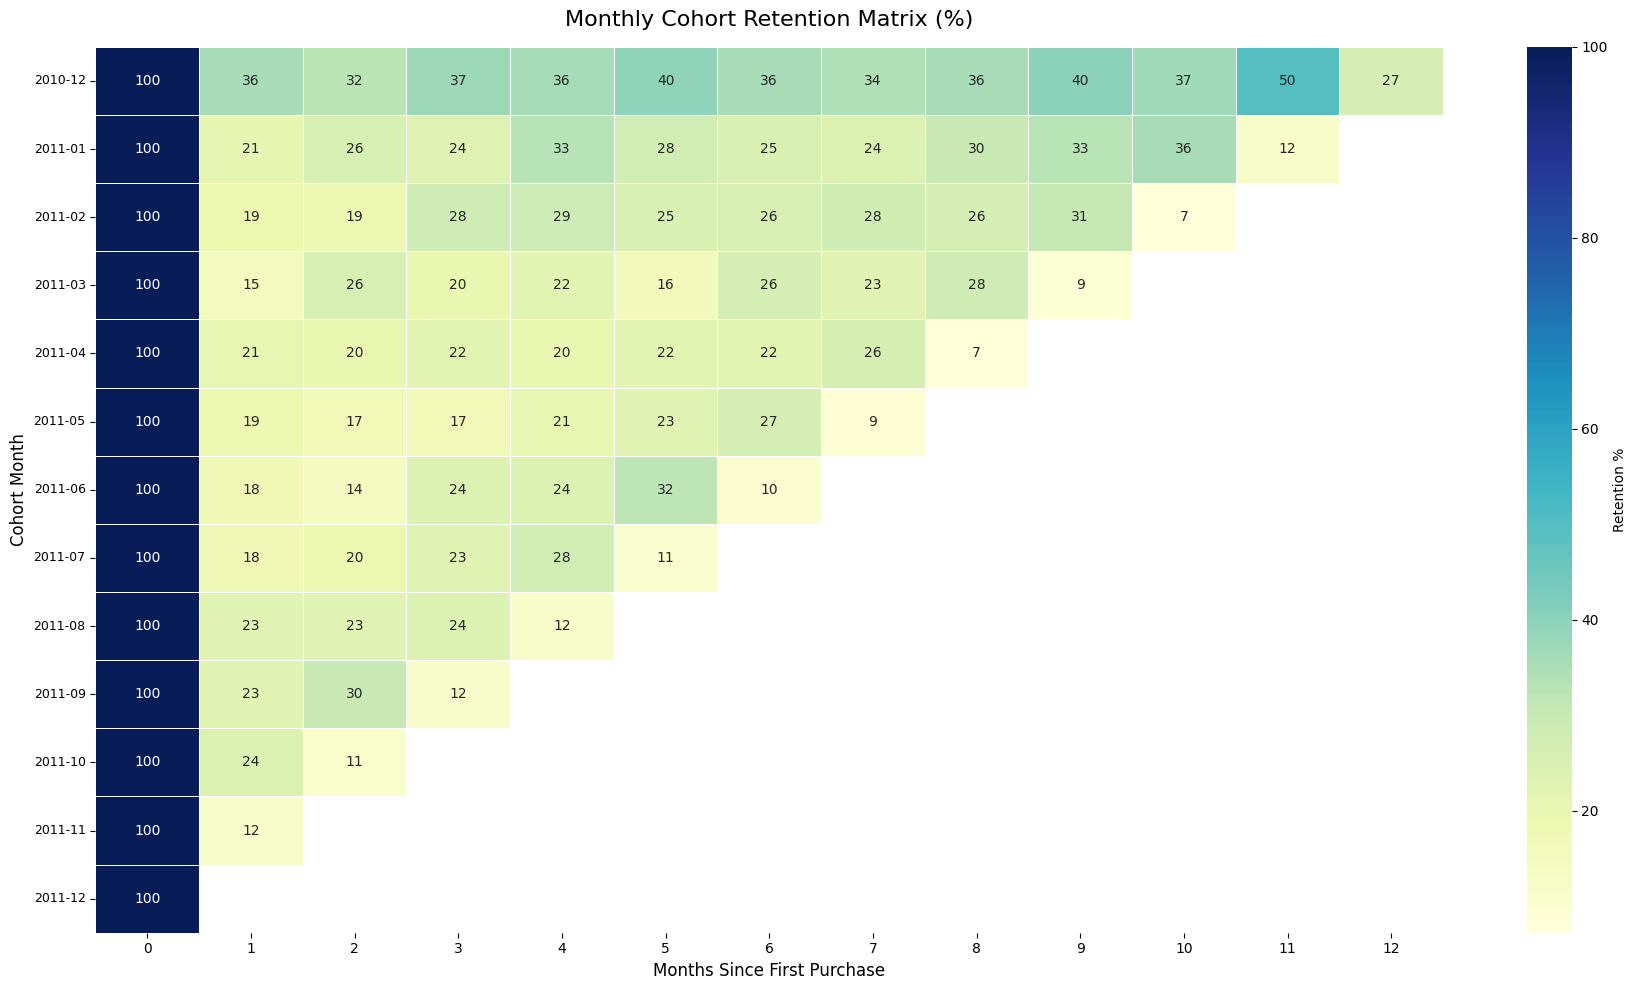

In [14]:
#  Retention Heatmap
fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Retention %"}
)

ax.set_title("Monthly Cohort Retention Matrix (%)", fontsize=16, pad=15)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Cohort Month", fontsize=12)
ax.set_yticklabels(
    [str(p) for p in retention_matrix.index], rotation=0, fontsize=9
)

plt.tight_layout()
plt.savefig("/content/outputs/charts/17_cohort_retention_heatmap.png", dpi=150)
plt.show()

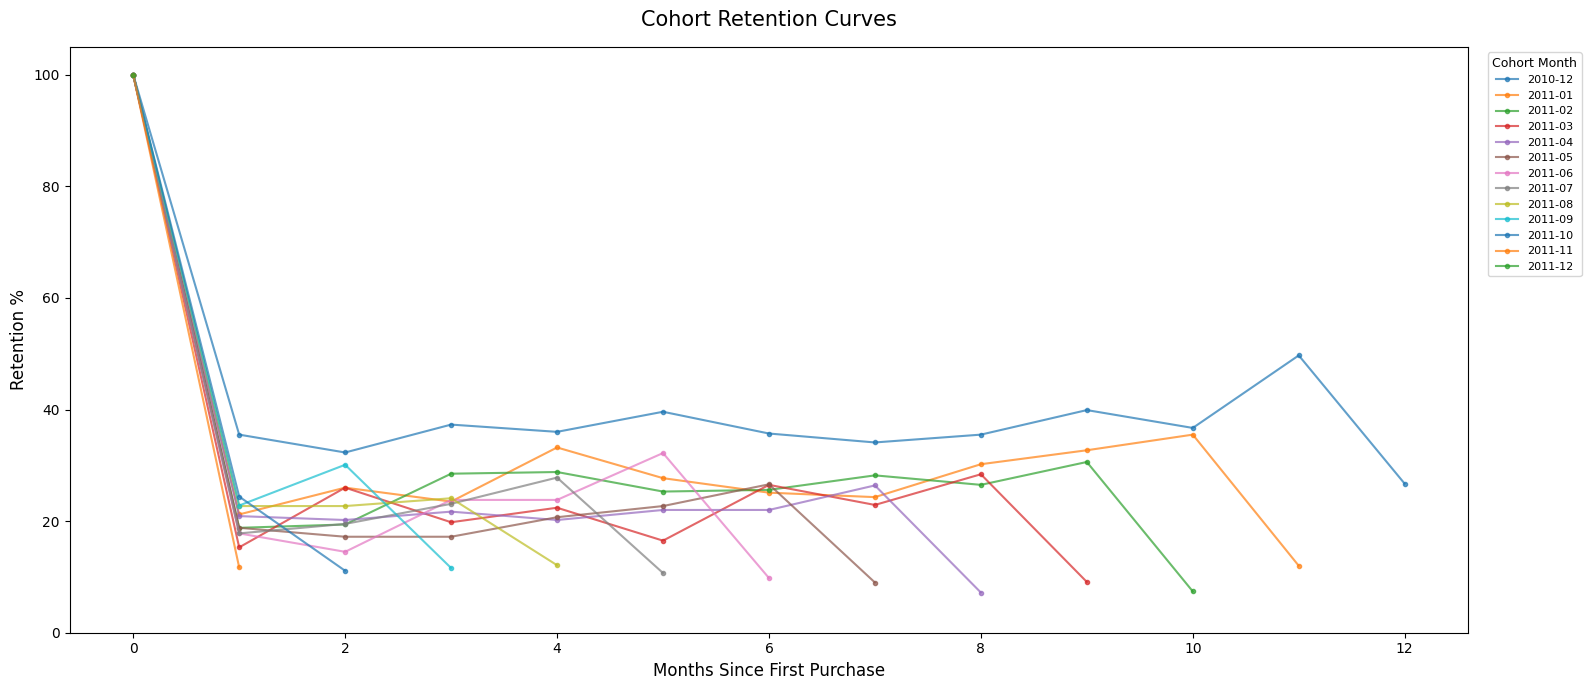

In [15]:
# Retention Curve
fig, ax = plt.subplots(figsize=(16, 7))

for i, cohort in enumerate(retention_matrix.index):
    row = retention_matrix.loc[cohort].dropna()
    ax.plot(
        row.index,
        row.values,
        marker="o",
        markersize=3,
        linewidth=1.5,
        alpha=0.7,
        label=str(cohort)
    )

ax.set_title("Cohort Retention Curves", fontsize=15, pad=15)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Retention %", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(
    title="Cohort Month",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
plt.savefig("/content/outputs/charts/18_cohort_retention_curves.png", dpi=150)
plt.show()

In [16]:
# Average Retention by Month
avg_retention = retention_matrix.mean(axis=0).round(2)

print("Average Retention by Month Since First Purchase")
for idx, val in avg_retention.items():
    print(f"Month {idx:>2}: {val:.1f}%")

Average Retention by Month Since First Purchase
Month  0: 100.0%
Month  1: 20.6%
Month  2: 21.7%
Month  3: 23.1%
Month  4: 25.0%
Month  5: 24.6%
Month  6: 24.5%
Month  7: 24.1%
Month  8: 25.6%
Month  9: 28.1%
Month 10: 26.5%
Month 11: 30.9%
Month 12: 26.7%


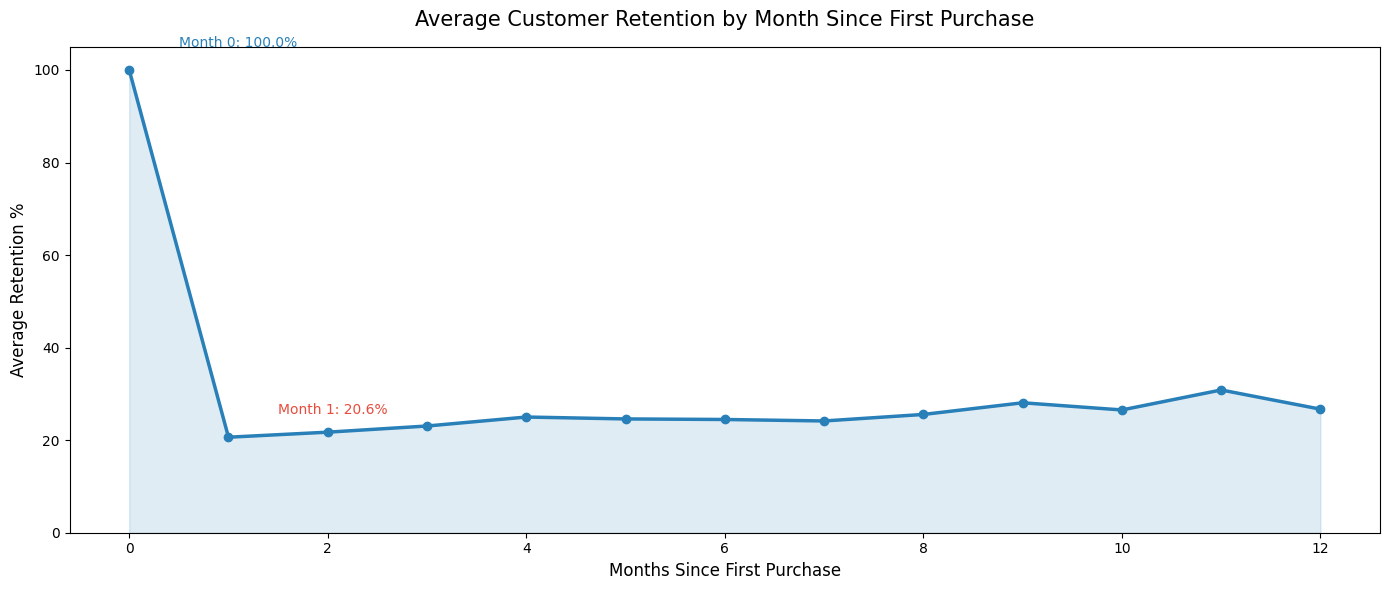

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    avg_retention.index,
    avg_retention.values,
    color="#2980b9",
    marker="o",
    markersize=6,
    linewidth=2.5
)

ax.fill_between(
    avg_retention.index,
    avg_retention.values,
    alpha=0.15,
    color="#2980b9"
)

ax.set_title("Average Customer Retention by Month Since First Purchase",
             fontsize=15, pad=15)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Average Retention %", fontsize=12)
ax.set_ylim(0, 105)

# Annotate month 0 and month 1 drop
month_0 = avg_retention.iloc[0]
month_1 = avg_retention.iloc[1] if len(avg_retention) > 1 else None

ax.annotate(
    f"Month 0: {month_0:.1f}%",
    xy=(0, month_0), xytext=(0.5, month_0 + 5),
    fontsize=10, color="#2980b9"
)

if month_1:
    ax.annotate(
        f"Month 1: {month_1:.1f}%",
        xy=(1, month_1), xytext=(1.5, month_1 + 5),
        fontsize=10, color="#e74c3c"
    )

plt.tight_layout()
plt.savefig("/content/outputs/charts/19_avg_retention_curve.png", dpi=150)
plt.show()

In [18]:
# Average retention from month 1 onwards, excludes month 0 which is always 100%
retention_from_month1 = retention_matrix.iloc[:, 1:].mean(axis=1).round(2)

best_cohort  = retention_from_month1.idxmax()
worst_cohort = retention_from_month1.idxmin()

In [19]:
print(f"Best performing cohort : {best_cohort} - avg retention {retention_from_month1[best_cohort]:.1f}%")
print(f"Worst performing cohort : {worst_cohort} — avg retention {retention_from_month1[worst_cohort]:.1f}%")

Best performing cohort : 2010-12 - avg retention 36.6%
Worst performing cohort : 2011-11 — avg retention 11.7%


In [20]:
print(f"All cohorts ranked by retention (month 1+):")
print(retention_from_month1.sort_values(ascending=False).to_string())

All cohorts ranked by retention (month 1+):
CohortMonth
2010-12    36.58
2011-01    26.49
2011-02    23.91
2011-09    21.50
2011-03    20.77
2011-08    20.40
2011-06    20.32
2011-04    20.08
2011-07    19.78
2011-05    18.89
2011-10    17.75
2011-11    11.70
2011-12      NaN
Freq: M


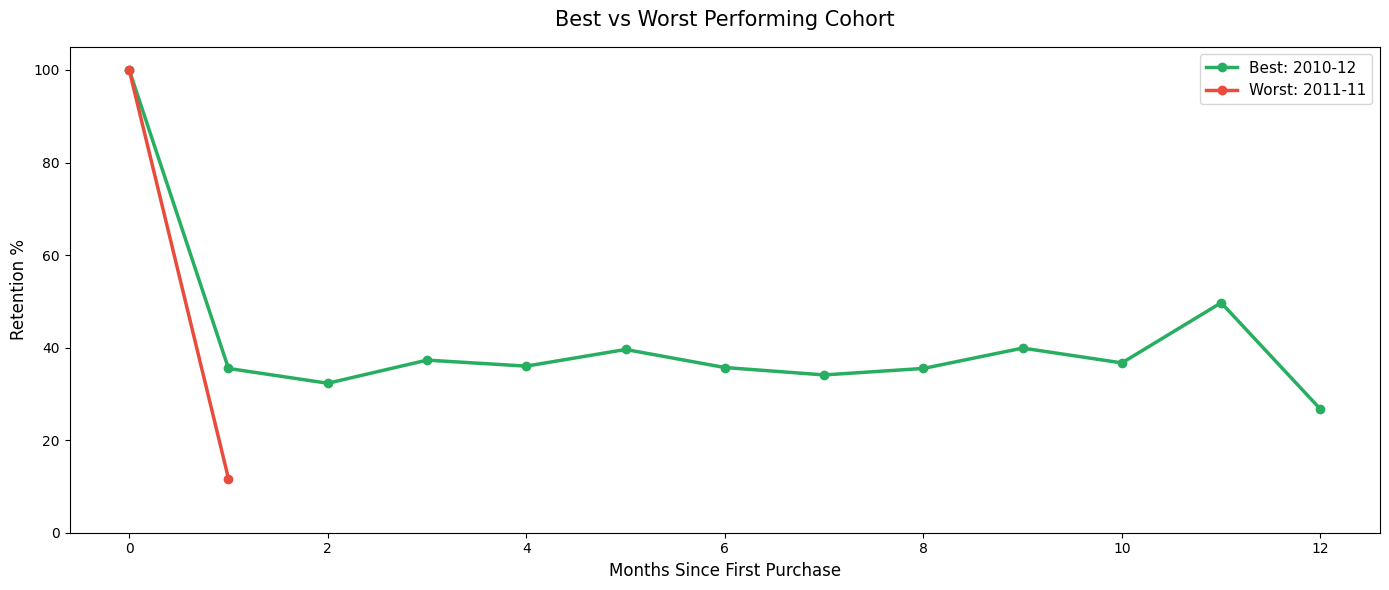

In [21]:
# Plot best vs worst cohort side by side
fig, ax = plt.subplots(figsize=(14, 6))

best_row  = retention_matrix.loc[best_cohort].dropna()
worst_row = retention_matrix.loc[worst_cohort].dropna()

ax.plot(best_row.index, best_row.values,
        color="#27ae60", marker="o", linewidth=2.5,
        label=f"Best: {best_cohort}")

ax.plot(worst_row.index, worst_row.values,
        color="#e74c3c", marker="o", linewidth=2.5,
        label=f"Worst: {worst_cohort}")

ax.set_title("Best vs Worst Performing Cohort", fontsize=15, pad=15)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Retention %", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("/content/outputs/charts/20_best_vs_worst_cohort.png", dpi=150)
plt.show()

In [22]:
# Save retention matrix
retention_matrix.to_csv("/content/outputs/tables/cohort_retention_matrix.csv")

In [23]:
print(f"Worst cohort is NaN: {pd.isna(worst_cohort)}")

Worst cohort is NaN: False
